In [2]:
from google.colab import files

uploaded = files.upload()

Saving Sample - Superstore.csv to Sample - Superstore (1).csv


In [3]:
!pip install prophet

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet

In [13]:
import os
print(os.listdir())


['.config', 'Sample - Superstore (1).csv', 'Sample - Superstore.csv', 'sample_data']


In [18]:
import os
os.listdir()

['.config',
 'Sample - Superstore (1).csv',
 'Sample - Superstore.csv',
 'sample_data']

In [21]:
df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')

In [22]:
print(df.columns)

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')


In [23]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [24]:
sales = df.groupby('Order Date')['Sales'].sum().reset_index()

sales.columns = ['ds', 'y']

sales.head()

,ds,y
0,2014-01-03,16.448
1,2014-01-04,288.060
2,2014-01-05,19.536
3,2014-01-06,4407.100
4,2014-01-07,87.158


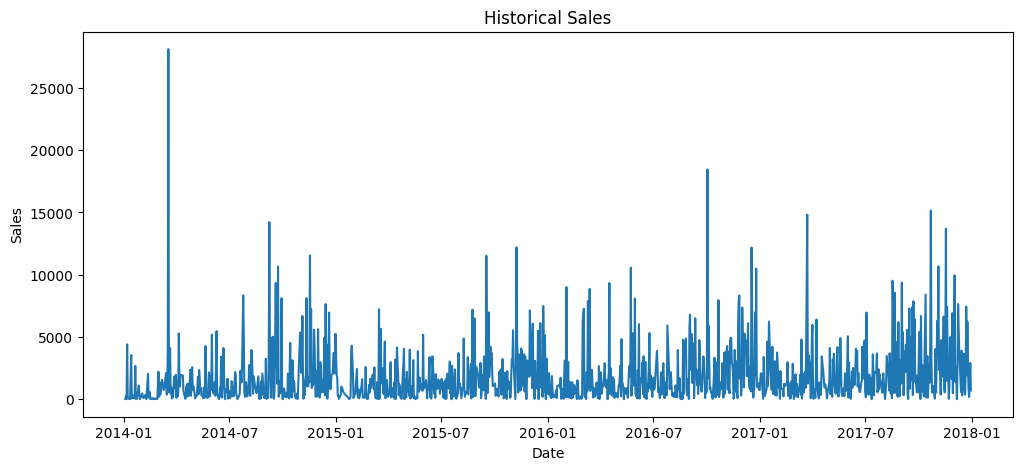

In [25]:
plt.figure(figsize=(12,5))
plt.plot(sales['ds'], sales['y'])
plt.title('Historical Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

In [26]:
model = Prophet()

model.fit(sales)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [27]:
future = model.make_future_dataframe(periods=30)

forecast = model.predict(future)

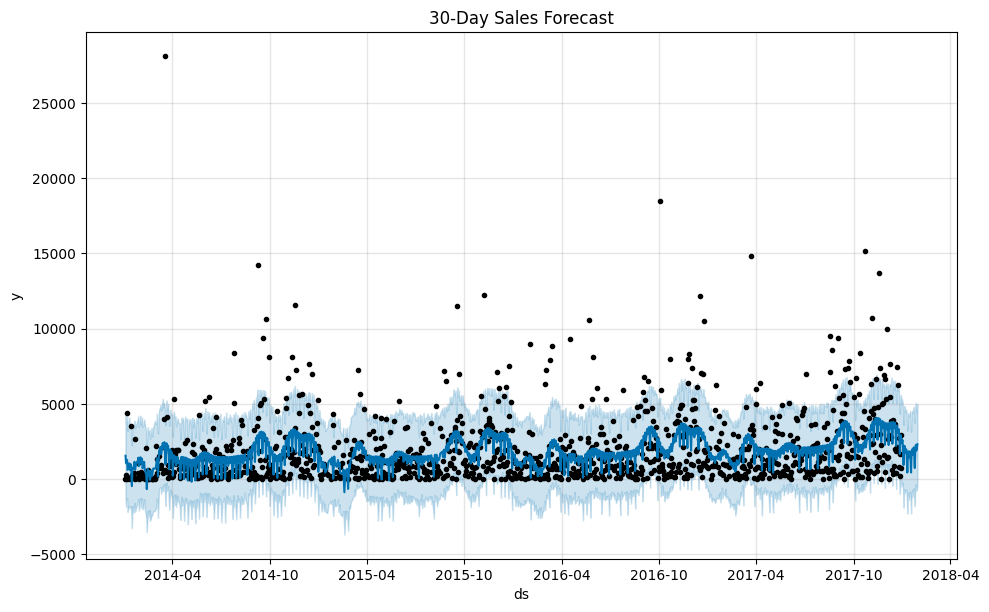

In [28]:
fig1 = model.plot(forecast)
plt.title("30-Day Sales Forecast")
plt.show()

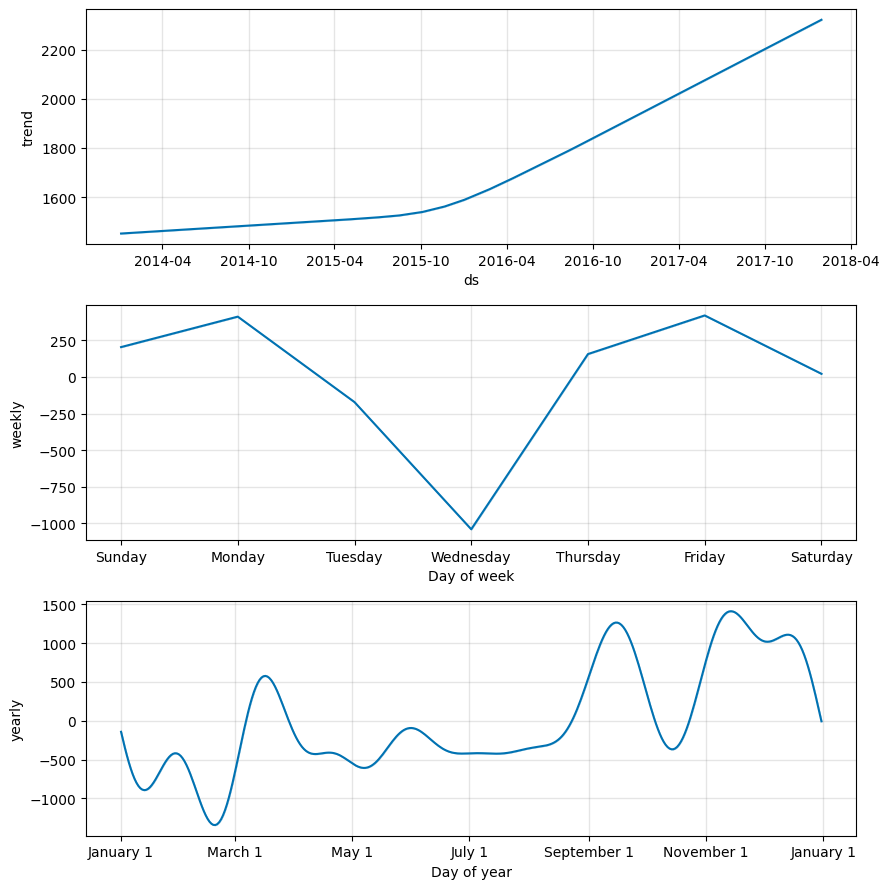

In [29]:
fig2 = model.plot_components(forecast)
plt.show()

In [30]:
train = sales[:-30]
test = sales[-30:]

In [31]:
model = Prophet()
model.fit(train)

future = model.make_future_dataframe(periods=30)

forecast = model.predict(future)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [32]:
pred = forecast[['ds','yhat']].tail(30)

In [33]:
from sklearn.metrics import mean_absolute_error

merged = test.merge(pred,on='ds')

mae = mean_absolute_error(
    merged['y'],
    merged['yhat']
)

print("MAE:", mae)

MAE: 1962.2029921289943


The Prophet forecasting model achieved a Mean Absolute Error (MAE) of 1962.20 on the test data. This indicates that the predicted sales values differ from the actual sales by approximately 1962 units on average. Considering the variability in daily sales, the model captures the overall trend and seasonality reasonably well.

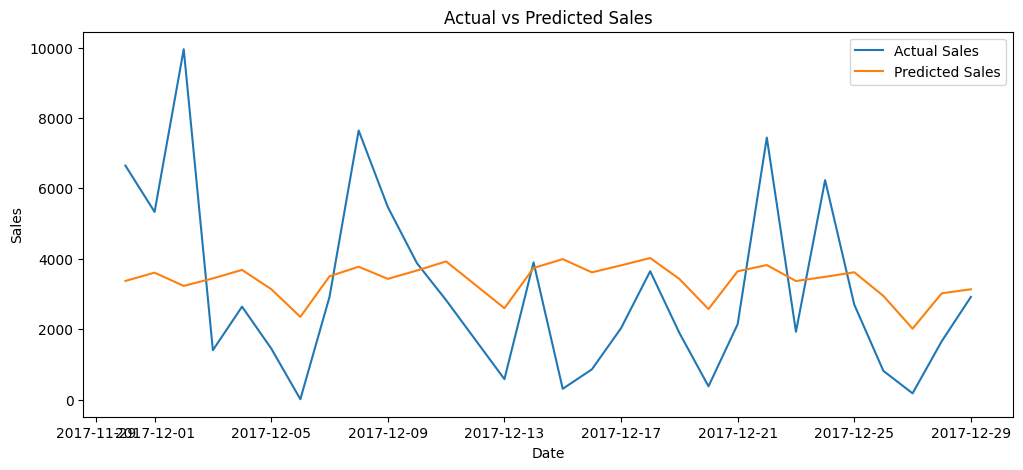

In [36]:
plt.figure(figsize=(12,5))
plt.plot(merged['ds'], merged['y'], label='Actual Sales')
plt.plot(merged['ds'], merged['yhat'], label='Predicted Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.title('Actual vs Predicted Sales')
plt.legend()
plt.show()